# 5. Stability of tilt relationships across surface footprints

The best footprint should not be selected from the strongest isolated relationship. We look for polarity-consistent behavior that remains interpretable across neighbouring scales.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / "seacofs_tilt_tools.py").exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or one of its subfolders")
for path in (ANALYSIS_ROOT, HERE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
import seacofs_tilt_tools as tilt
import footprint_tools as ft
sns.set_theme(style="whitegrid", context="notebook")
palette = {"AE":"#c44e52", "CE":"#4c72b0"}

data = ft.load_cache()
filled = data[(data.footprint_kind == "Filled") & (data.pv_averaging == "nonlinear")].copy()
score = ft.footprint_scorecard(data)


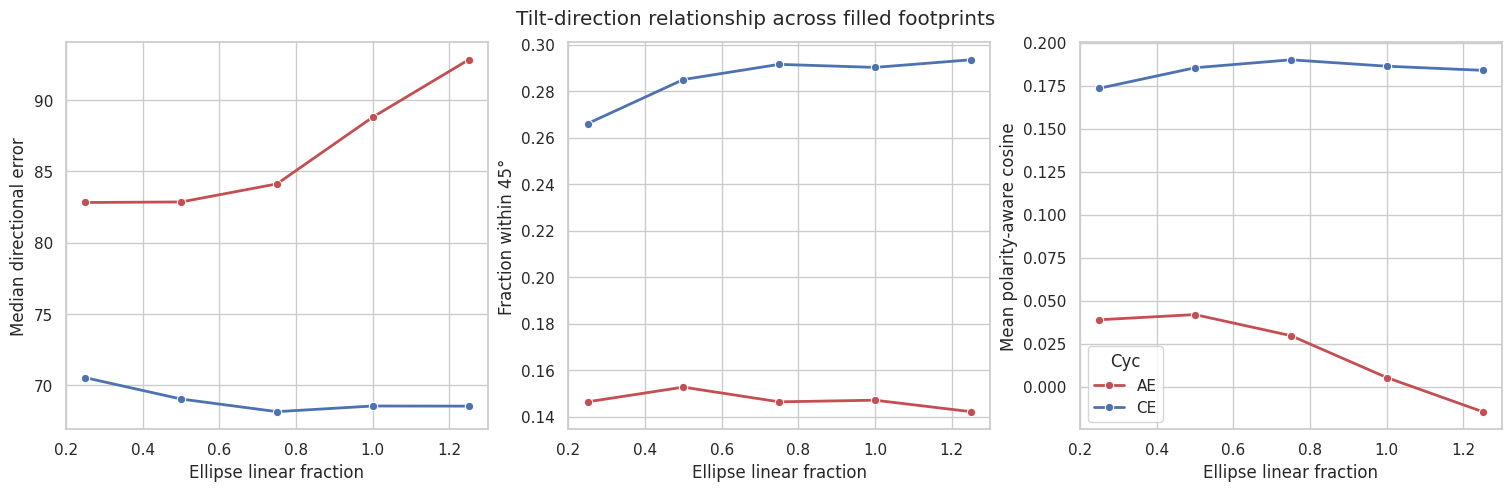

In [2]:
filled_score=score[score.footprint_kind.eq("Filled")]
fig,axes=plt.subplots(1,3,figsize=(15,4.8),constrained_layout=True)
for ax,column,label in zip(axes,
    ["median_error_deg","fraction_within_45","mean_alignment"],
    ["Median directional error","Fraction within 45°","Mean polarity-aware cosine"]):
    sns.lineplot(data=filled_score,x="ellipse_frac",y=column,hue="Cyc",palette=palette,marker="o",lw=2,ax=ax)
    ax.set(xlabel="Ellipse linear fraction",ylabel=label)
    if ax is not axes[-1] and ax.legend_: ax.legend_.remove()
fig.suptitle("Tilt-direction relationship across filled footprints"); plt.show()

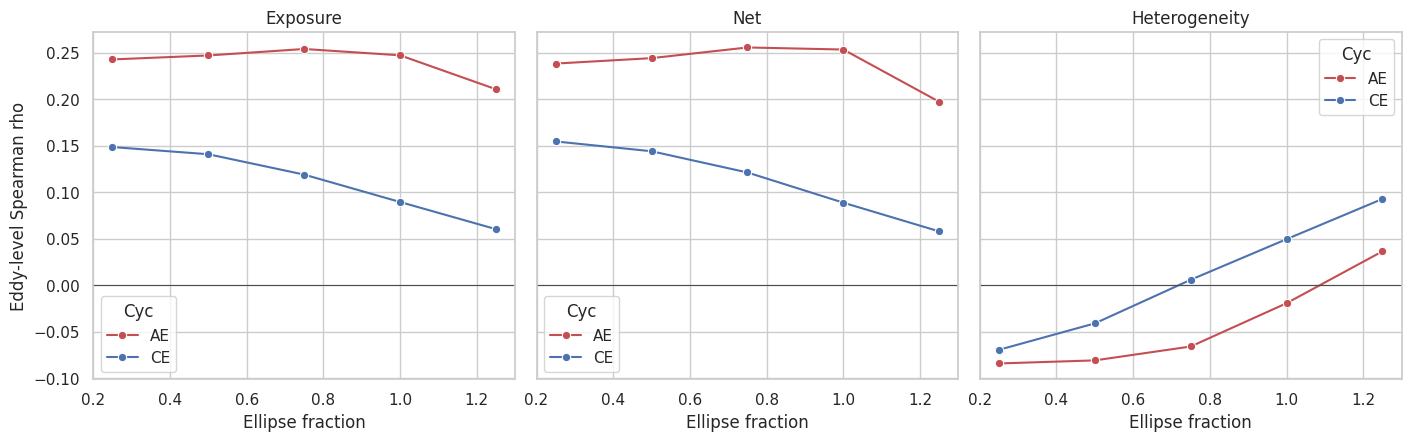

In [3]:
from scipy.stats import spearmanr
rows=[]
for (cyc,footprint),part in filled.groupby(["Cyc","footprint"]):
    eddy=part.groupby("Eddy").agg(tilt=("TiltDis","median"),exposure=("PV_grad_topo_mean_local_mag","median"),
                                    net=("PV_grad_topo_mag","median"),heterogeneity=("topo_cancellation_gap","median"))
    for predictor in ["exposure","net","heterogeneity"]:
        use=eddy[["tilt",predictor]].replace([np.inf,-np.inf],np.nan).dropna()
        rho=spearmanr(use.tilt,use[predictor]).statistic if len(use)>=10 else np.nan
        rows.append({"Cyc":cyc,"footprint":footprint,"ellipse_frac":part.ellipse_frac.iloc[0],"predictor":predictor,"rho":rho})
corr=pd.DataFrame(rows)
fig,axes=plt.subplots(1,3,figsize=(14,4.3),sharey=True,constrained_layout=True)
for ax,predictor in zip(axes,["exposure","net","heterogeneity"]):
    sns.lineplot(data=corr[corr.predictor.eq(predictor)],x="ellipse_frac",y="rho",hue="Cyc",palette=palette,marker="o",ax=ax)
    ax.axhline(0,color="0.3",lw=.8); ax.set(title=predictor.title(),xlabel="Ellipse fraction",ylabel="Eddy-level Spearman rho")
plt.show()